# Logistic Regression Model - Baseline for Model Comparisons

## Introduction

This notebook is part of a broader modeling pipeline aimed at predicting customer churn using multiple modeling approaches. Previous steps in the pipeline focused on data exploration and feature engineering, resulting in a structured dataset with well-defined variables capturing customer behavior and service usage.

The objective of this stage is to establish a baseline modeling framework using logistic regression. This model serves two key purposes. First, it provides an interpretable benchmark that allows us to understand the primary drivers of churn. Second, it defines a consistent evaluation and validation approach that will be reused when comparing more complex models in subsequent notebooks.

Rather than focusing solely on binary classification, the model is designed to estimate churn probabilities and rank customers by risk. This enables more flexible and actionable decision-making, such as prioritizing high-risk customers for retention efforts.

The modeling process follows a structured top-down approach, starting from a full specification and iteratively simplifying the model based on statistical tests and cross-validation performance. In addition, we explicitly separate model estimation from decision-making by addressing classification threshold selection as a distinct step.

The final output of this notebook is a validated and interpretable baseline model, along with a selected classification threshold. These results will be used as a reference point for evaluating alternative modeling approaches, including tree-based methods, support vector machines, and neural networks, in subsequent stages of the project.

## Table of Contents

1. [Modeling Considerations](#modeling-considerations)
2. [Model Definition and Training Procedure](#model-definition-and-training-procedure)
3. [Helper Function for Model Estimation](#helper-functions-for-model-estimation)
4. [Model Estimation and Simplification](#model-estimation-and-simplification)
5. [Threshold Selection](#threshold-selection)
6. [Final Model Evaluation on Test Data](#final-model-evaluation-on-test-data)
7. [Executive Summary](#executive-summary)
8. [Operational Use Case](#operational-use-case)

## Modeling Considerations

Before fitting the model, we outline several key considerations that influence both model behavior and downstream decision-making.

---

### Class Imbalance

The target variable exhibits moderate class imbalance, with approximately 26.5% of customers churning.

While logistic regression does not require perfectly balanced classes, the underlying distribution directly affects predicted probabilities and, consequently, classification decisions. In particular, the baseline churn rate is reflected in the model intercept and influences how probabilities should be interpreted.

Given that the imbalance is not severe, we do not apply rebalancing techniques such as weighting or resampling. Instead, we explicitly account for this imbalance at the decision stage by selecting an appropriate classification threshold, rather than relying on the default value of 0.5.

---

### Feature Scaling

Feature scaling can improve numerical stability and is often necessary when regularization is applied. However, in this case, the majority of variables are binary or one-hot encoded, and the remaining numerical features lie within comparable ranges.

As a result, scaling is not required for model stability. Retaining the original scale also preserves the interpretability of model coefficients, which is a key objective of this baseline model.

---

### Feature Representation

During feature engineering, several service-related variables with overlapping information were simplified into two integer-based summary features. This reduced a more complex categorical structure into a more compact representation while preserving most of the relevant information.

Alternative categorical representations were also considered during feature engineering, but they did not lead to a meaningful improvement in model performance. We therefore retain the integer-based representation, as it provides a simpler and more efficient feature space without materially reducing predictive capability.

---

### Summary

Overall, the dataset is well-suited for logistic regression and requires minimal additional preprocessing. Categorical variables are encoded using one-hot encoding, while numerical variables are retained in their original form.

These choices reflect a deliberate balance between interpretability, simplicity, and predictive capability. Rather than introducing unnecessary complexity, the focus is on building a stable and transparent baseline model that can serve as a reference point for more advanced approaches in subsequent stages.

These decisions are intentionally conservative, ensuring that any performance improvements observed in more complex models can be attributed to model capability rather than preprocessing choices.

With these considerations in place, we proceed to defining the model and training procedure.

## **Model Definition and Training Procedure**

Logistic regression is used as the baseline classification model, providing an interpretable reference point for evaluating more complex models in subsequent stages.

Categorical variables are encoded using one-hot encoding prior to model estimation, and an intercept term is added explicitly to the design matrix, as required by the modeling framework.

The model is estimated using maximum likelihood without regularization. This choice prioritizes interpretability and enables direct coefficient interpretation, as well as likelihood-based comparison of nested model specifications.

Model development follows a top-down approach to feature selection. We begin with a full specification including all candidate variables and iteratively remove features that contribute the least, based on both statistical significance and predictive performance.

At each step, model performance is evaluated using 5-fold cross-validation, with particular attention to ROC AUC and accuracy. This ensures that any simplification improves or at least preserves generalization performance, rather than overfitting to the training data.

In parallel, likelihood-ratio tests are used to compare nested models and assess whether removing variables results in a statistically meaningful reduction in model fit.

The objective of this process is to identify a simplified and interpretable model that retains strong predictive performance. Feature removal is stopped once further simplification leads to a consistent degradation in cross-validated performance or a statistically significant loss of fit.

After selecting the final model specification, the model is retrained on the full training dataset and subsequently evaluated on a held-out test set to obtain an unbiased estimate of performance.

## Model Implementation

This section implements the modeling workflow described above, the conceptual approach into a reusable and consistent pipeline.

The training and test datasets are loaded and prepared for model estimation. Feature preparation includes identifying categorical and numerical variables, applying one-hot encoding to categorical features, and constructing design matrices suitable for logistic regression.

To ensure consistency across all model specifications, a helper function is defined to standardize the preparation of input data. This function handles encoding, column alignment, and intercept inclusion, ensuring that both baseline and subsequent model variants are estimated on a consistent feature space.

This setup allows the modeling process to remain modular and reproducible, particularly when evaluating multiple model specifications and performing cross-validation.

The implementation proceeds in the following steps:

1. Load training and test data using Polars  
2. Define target and predictor variables  
3. Convert data to pandas for compatibility with statsmodels  
4. Define a helper function to construct the design matrix:
   - applies one-hot encoding to categorical variables  
   - aligns feature columns across datasets  
   - adds an intercept term  
   - returns `X` and `y`  
5. Fit the baseline model using the full feature set  

We begin by loading the data.

In [40]:
import polars as pl

# Load datasets
train_df = pl.read_csv("./data/processed/06_dpp_train_df.csv")
test_df = pl.read_csv("./data/processed/06_dpp_test_df.csv")

selected_columns= ['SeniorCitizenRelevel',
                            'Partner',
                            'Dependents',
                            'tenure',
                            'Contract',
                            'PaperlessBilling',
                            'MonthlyCharges',
                            'Churn',
                            'AdditionalInternetServicesCount',
                            'StreamingServicesCount',
                            'MC_x_Additional',
                            'MC_x_Streaming',
                            'PaymentMethod_bin_3']

# select only the columns for linear models
train_df = train_df.select(selected_columns)
test_df = test_df.select(selected_columns)

# Quick sanity check
print(train_df.shape)
print(test_df.shape)

(5634, 13)
(1409, 13)


With the data loaded, we now define the target variable and feature set, and convert the data to pandas for model estimation.

In [41]:
train_df.columns

['SeniorCitizenRelevel',
 'Partner',
 'Dependents',
 'tenure',
 'Contract',
 'PaperlessBilling',
 'MonthlyCharges',
 'Churn',
 'AdditionalInternetServicesCount',
 'StreamingServicesCount',
 'MC_x_Additional',
 'MC_x_Streaming',
 'PaymentMethod_bin_3']

In [42]:
categorical_cols = [
    "SeniorCitizenRelevel", "Partner", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount", "MC_x_Additional", 'MC_x_Streaming'
]

target_col = "Churn"

# Define the order of categories for categorical variables, first will be dropped when one hot encoding
categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

# check if we are not forgetting any column
set(categorical_cols + numerical_cols + [target_col]) == set(train_df.columns)

True

### **Model Estimation and Simplification**

With the target variable and feature groups defined, we establish a helper function to standardize the preparation of the design matrix.

This function transforms the input data into a format suitable for statsmodels, including one-hot encoding of categorical variables, alignment of feature columns when needed, and explicit addition of the intercept term.

Model estimation itself is performed directly using the statsmodels API. Given the simplicity of the fitting interface, introducing an additional abstraction for model fitting would not provide meaningful benefits and would unnecessarily complicate the workflow.

Separating data preparation into a reusable function ensures consistency across different model specifications and simplifies the iterative process of model simplification. This structure is particularly useful when repeatedly re-estimating models during feature selection and cross-validation.

In [43]:
# preparation will be reused for other models
from src.utils.data_preparation_models import prepare_linear_features

We now fit the logistic regression model using the prepared design matrix. Model estimation is performed directly using the statsmodels API, as its interface is sufficiently simple and does not warrant additional abstraction.

In [44]:


X, y = prepare_linear_features(
    df=train_df,
    categorical_cols=categorical_cols,
    numerical_cols=numerical_cols,
    categorical_orders=categorical_orders
)


In [45]:
import statsmodels.api as sm
baseline_model = sm.Logit(y, X)
baseline_model_fit = baseline_model.fit()

Optimization terminated successfully.
         Current function value: 0.420463
         Iterations 8


The model converged successfully after 8 iterations using Newton–Raphson optimization. This is within the expected range for logistic regression and indicates stable estimation without numerical issues.

In [46]:
print(baseline_model_fit.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5619
Method:                           MLE   Df Model:                           14
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2733
Time:                        23:44:02   Log-Likelihood:                -2368.9
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.7258      0.158    -10.944      0.000      -2.035      -1.417
tenure                                  -0.0323      

### **Baseline Model Interpretation**

The baseline model provides an initial view of how the selected variables relate to customer churn, highlighting several clear patterns across behavioral, pricing, and demographic factors.

---

**Core behavioral and contract variables**

- **tenure** has a strong negative coefficient (-0.0323, p < 0.001), indicating that customers with longer tenure are significantly less likely to churn.

- **Contract type** is one of the strongest predictors:
  - Contract_One year (-0.7517, p < 0.001)  
  - Contract_Two year (-1.5336, p < 0.001)  
  Both show large negative effects relative to month-to-month contracts, with two-year contracts having the strongest impact.

---

**Pricing and billing**

- **MonthlyCharges** has a positive and highly significant coefficient (0.0243, p < 0.001), indicating that higher costs are associated with increased churn risk.

- **PaperlessBilling_Yes** shows a strong positive effect (0.4342, p < 0.001), suggesting higher churn among customers using paperless billing.

- **PaymentMethod_bin_3_Electronic check** has a strong positive and significant effect (0.4597, p < 0.001), making it one of the most important churn indicators in the model.

- **PaymentMethod_bin_3_Mailed check** (-0.0234, p = 0.831) does not show a meaningful effect relative to the reference category.

---

**Demographics**

- **SeniorCitizenRelevel_Yes** has a positive and statistically significant coefficient (0.2519, p = 0.008), indicating higher churn likelihood among senior customers.

- **Dependents_Yes** shows a negative and significant effect (-0.2328, p = 0.020), suggesting that customers with dependents are less likely to churn.

- **Partner_Yes** (0.0657, p = 0.450) does not contribute meaningfully once other variables are accounted for.

---

**Service-related features and interactions**

- **AdditionalInternetServicesCount** shows a negative and statistically significant effect (-0.2942, p = 0.042), indicating that customers with more additional services are less likely to churn.

- **StreamingServicesCount** (0.0158, p = 0.942) does not exhibit a meaningful relationship with churn.

- Interaction terms:
  - MC_x_Additional (-0.0002, p = 0.897)  
  - MC_x_Streaming (0.0011, p = 0.680)  
  do not show statistical significance and suggest limited contribution in their current form.

---

Overall, the model identifies contract type, pricing, customer tenure, and selected behavioral characteristics as the primary drivers of churn. While most service-related interaction terms do not provide additional explanatory power, the inclusion of aggregated service features offers some insight into customer engagement patterns.

**Summary**

The model highlights a small set of strong and consistent drivers of churn, particularly contract type, tenure, pricing, and selected billing characteristics. 

At the same time, several variables — especially interaction terms and some service-related features — contribute little in the presence of these stronger predictors and will be considered for removal in the next step.

### Feature Selection Strategy

We adopt a top-down feature selection approach, starting from the full model and iteratively removing variables to arrive at a more compact and interpretable specification.

At each step, only a single variable is removed. This is important because some predictors capture overlapping aspects of customer behavior, and removing one variable can affect the statistical significance of others. Evaluating variables one at a time allows these dependencies to be observed and reduces the risk of prematurely discarding useful predictors.

The selection process is guided primarily by statistical significance. In each iteration, the variable with the highest p-value is identified as a candidate for removal. This procedure continues until all remaining variables are statistically significant or further simplification leads to a loss of important model structure.

Categorical variables represented by multiple dummy columns are treated as a single unit. All associated dummy variables are either retained or removed together. While removing individual categories is technically possible, it would redefine the reference group and complicate interpretation. Given the current feature engineering setup, consistency and interpretability are prioritized.

This stepwise approach enables systematic simplification while preserving the core explanatory structure of the model.

### Evaluation Metrics

To assess model performance, we use a combination of threshold-independent and threshold-dependent metrics. This is particularly important in churn prediction, where the target class is typically imbalanced and different metrics capture different aspects of model quality.

**ROC-AUC** measures the model’s ability to rank churners above non-churners across all possible thresholds. It reflects overall discriminative power, but can be overly optimistic in imbalanced settings.

**PR-AUC (Average Precision)** focuses on the model’s performance on the positive class (churners). It captures the trade-off between precision and recall and is more informative when the positive class is rare, as it emphasizes how well true churners are identified without introducing too many false positives.

**Accuracy** measures the proportion of correctly classified observations. However, in imbalanced datasets, it can be misleading, as predicting the majority class can yield high accuracy without meaningful predictive power.

**Precision** measures the proportion of predicted churners that are actually churners. It reflects how reliable positive predictions are and is important when intervention costs are high.

**Recall (Sensitivity)** measures the proportion of actual churners that are correctly identified. It captures the model’s ability to detect at-risk customers and is critical when missing a churner is costly.

**F1 Score** is the harmonic mean of precision and recall. It provides a balanced view when both false positives and false negatives are important.

In this project, ROC-AUC and PR-AUC are used to evaluate overall model quality, while precision, recall, and F1 score guide the selection of an appropriate classification threshold for business use.

### **First Simplification**

The variable with the highest p-value is `StreamingServicesCount` (p = 0.942). However, the model also includes the interaction term `MC_x_Streaming` (p = 0.680). To preserve the standard hierarchical structure of the model, interaction terms are retained only when their corresponding main effects are present. As a result, `StreamingServicesCount` is not considered for removal at this stage.

The next highest p-value is associated with the interaction term `MC_x_Additional` (p = 0.897). Removing this term does not violate the hierarchical structure, making it the first candidate for elimination.

The corresponding main effects, `MonthlyCharges` and `AdditionalInternetServicesCount`, are retained in the model.

Defnining cross validation helper function, we will reuse during simplifying model structure, and we also import helper function for calculating the pre selected metrics, so it stays consistent across entire modelling process.

In [47]:
from src.utils.classification_metrics import compute_classification_metrics

In [48]:
import pandas as pd
import statsmodels.api as sm

from scipy.stats import chi2
from sklearn.model_selection import StratifiedKFold


def cross_validate_logit_models(
    df,
    baseline_categorical_cols,
    baseline_numerical_cols,
    reduced_categorical_cols,
    reduced_numerical_cols,
    categorical_orders=None,
    target_col="Churn",
    n_splits=5,
    threshold=0.5,
    random_state=42
):
    """
    Compare baseline and reduced logistic regression models using stratified k-fold CV.

    For each fold:
    - fit both models on the training portion
    - evaluate predictive performance on the validation portion
    - compute LR test on the fold training data

    Returns
    -------
    fold_results : pd.DataFrame
        Fold-level comparison table.
    summary_results : pd.DataFrame
        Mean metrics across folds.
    """

    if categorical_orders is None:
        categorical_orders = {}

    if hasattr(df, "to_pandas"):
        df = df.to_pandas()

    y_full = (
        pd.to_numeric(df[target_col].replace({"Yes": 1, "No": 0}), errors="raise")
        .astype(int)
        .copy()
    )

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    results = []

    for fold_idx, (train_idx, valid_idx) in enumerate(skf.split(df, y_full), start=1):
        df_train = df.iloc[train_idx].copy()
        df_valid = df.iloc[valid_idx].copy()

        # Baseline model
        X_train_base, y_train_base = prepare_linear_features(
            df=df_train,
            categorical_cols=baseline_categorical_cols,
            numerical_cols=baseline_numerical_cols,
            categorical_orders=categorical_orders,
            target_col=target_col
        )

        baseline_reference_columns = X_train_base.drop(columns="const").columns.tolist()

        X_valid_base, y_valid_base = prepare_linear_features(
            df=df_valid,
            categorical_cols=baseline_categorical_cols,
            numerical_cols=baseline_numerical_cols,
            categorical_orders=categorical_orders,
            target_col=target_col,
            reference_columns=baseline_reference_columns
        )

        baseline_result = sm.Logit(y_train_base, X_train_base).fit(disp=False)
        baseline_probs = baseline_result.predict(X_valid_base)
        baseline_preds = (baseline_probs >= threshold).astype(int)

        baseline_metrics = compute_classification_metrics(
            y_true=y_valid_base,
            y_pred=baseline_preds,
            y_prob=baseline_probs
        )

        # Reduced model
        X_train_red, y_train_red = prepare_linear_features(
            df=df_train,
            categorical_cols=reduced_categorical_cols,
            numerical_cols=reduced_numerical_cols,
            categorical_orders=categorical_orders,
            target_col=target_col
        )

        reduced_reference_columns = X_train_red.drop(columns="const").columns.tolist()

        X_valid_red, y_valid_red = prepare_linear_features(
            df=df_valid,
            categorical_cols=reduced_categorical_cols,
            numerical_cols=reduced_numerical_cols,
            categorical_orders=categorical_orders,
            target_col=target_col,
            reference_columns=reduced_reference_columns
        )

        reduced_result = sm.Logit(y_train_red, X_train_red).fit(disp=False)
        reduced_probs = reduced_result.predict(X_valid_red)
        reduced_preds = (reduced_probs >= threshold).astype(int)

        reduced_metrics = compute_classification_metrics(
            y_true=y_valid_red,
            y_pred=reduced_preds,
            y_prob=reduced_probs
        )

        # LR test on training fold
        lr_stat = 2 * (baseline_result.llf - reduced_result.llf)
        df_diff = int(baseline_result.df_model - reduced_result.df_model)
        lr_p_value = chi2.sf(lr_stat, df_diff) if df_diff > 0 else None

        results.append({
            "fold": fold_idx,

            "baseline_auc": baseline_metrics["auc"],
            "baseline_pr_auc": baseline_metrics["pr_auc"],
            "baseline_accuracy": baseline_metrics["accuracy"],
            "baseline_precision": baseline_metrics["precision"],
            "baseline_recall": baseline_metrics["recall"],
            "baseline_f1": baseline_metrics["f1"],

            "reduced_auc": reduced_metrics["auc"],
            "reduced_pr_auc": reduced_metrics["pr_auc"],
            "reduced_accuracy": reduced_metrics["accuracy"],
            "reduced_precision": reduced_metrics["precision"],
            "reduced_recall": reduced_metrics["recall"],
            "reduced_f1": reduced_metrics["f1"],

            "lr_stat": lr_stat,
            "df_diff": df_diff,
            "lr_p_value": lr_p_value
        })

    fold_results = (
        pd.DataFrame(results)
        .sort_values("fold")
        .reset_index(drop=True)
    )

    summary_results = (
        fold_results
        .drop(columns=["fold"])
        .mean(numeric_only=True)
        .round(4)
        .reset_index()
    )

    return fold_results, summary_results

**Removing `MC_x_Additional`**

In [49]:
baseline_categorical_cols = [
    "SeniorCitizenRelevel", "Partner", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

baseline_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount", "MC_x_Additional", 'MC_x_Streaming'
]

reduced_categorical_cols = [
    "SeniorCitizenRelevel", "Partner", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

reduced_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount", 'MC_x_Streaming'
]

target_col = "Churn"

categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

results_cv_1, summary_cv_1 = cross_validate_logit_models(
    df=train_df,
    baseline_categorical_cols=baseline_categorical_cols,
    baseline_numerical_cols=baseline_numerical_cols,
    reduced_categorical_cols=reduced_categorical_cols,
    reduced_numerical_cols=reduced_numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col,
)

In [50]:
results_cv_1

,fold,baseline_auc,baseline_pr_auc,baseline_accuracy,baseline_precision,baseline_recall,baseline_f1,reduced_auc,reduced_pr_auc,reduced_accuracy,reduced_precision,reduced_recall,reduced_f1,lr_stat,df_diff,lr_p_value
0,1,0.849941,0.655363,0.806566,0.673820,0.525084,0.590226,0.849957,0.655397,0.806566,0.673820,0.525084,0.590226,0.001290,1,0.971348
1,2,0.838750,0.628845,0.800355,0.659483,0.511706,0.576271,0.838685,0.628949,0.800355,0.659483,0.511706,0.576271,0.028093,1,0.866891
2,3,0.822298,0.610985,0.794144,0.635628,0.525084,0.575092,0.822270,0.610912,0.794144,0.635628,0.525084,0.575092,0.011806,1,0.913474
3,4,0.857064,0.648376,0.799468,0.654008,0.518395,0.578358,0.857092,0.648651,0.799468,0.654008,0.518395,0.578358,0.000390,1,0.984245
4,5,0.830101,0.631791,0.801066,0.659574,0.518395,0.580524,0.830153,0.631838,0.801066,0.659574,0.518395,0.580524,0.064360,1,0.799732


In [51]:
summary_cv_1

,index,0
0,baseline_auc,0.8396
1,baseline_pr_auc,0.6351
2,baseline_accuracy,0.8003
3,baseline_precision,0.6565
4,baseline_recall,0.5197
5,baseline_f1,0.5801
6,reduced_auc,0.8396
7,reduced_pr_auc,0.6351
8,reduced_accuracy,0.8003
9,reduced_precision,0.6565


### **Evaluation of First Simplification**

The likelihood ratio test across all folds shows no statistically significant difference between the baseline and reduced model (all p-values > 0.79, average p-value ≈ 0.91), indicating that removing the interaction term does not lead to a loss of model fit.

From a predictive perspective, the reduced model performs identically to the baseline across all evaluated metrics. ROC-AUC remains unchanged (0.8396), indicating that overall ranking ability is preserved. Importantly, PR-AUC — which is more informative in this imbalanced setting — is also unchanged (0.6351), confirming that the model’s ability to identify churners has not deteriorated.

Similarly, classification metrics such as accuracy (0.8003), precision (0.6565), recall (0.5197), and F1-score (0.5801) remain exactly the same on average across folds, indicating no impact on threshold-based performance.

Taken together, these results indicate that the removed interaction term does not contribute meaningful signal and can be safely excluded from the model. The simplified model therefore provides a more compact and interpretable specification without sacrificing predictive performance, either in global ranking (ROC-AUC) or positive-class identification (PR-AUC).

### Second simplification

We continue the simplification process by identifying the next candidate for removal, guided by statistical significance and the structural constraints of the model.

In [52]:
model_1_categorical_cols = [
    "SeniorCitizenRelevel", "Partner", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

model_1_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount", 'MC_x_Streaming'
]

categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "MultipleLines_releveled": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

X, y = prepare_linear_features(
    df=train_df,
    categorical_cols=model_1_categorical_cols,
    numerical_cols=model_1_numerical_cols,
    categorical_orders=categorical_orders
)

model_1 = sm.Logit(y, X)
model_1_fit = model_1.fit()
print(model_1_fit.summary())

Optimization terminated successfully.
         Current function value: 0.420465
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5620
Method:                           MLE   Df Model:                           13
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2733
Time:                        23:44:02   Log-Likelihood:                -2368.9
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.7215      0.1

The updated model confirms that `StreamingServicesCount` has the highest p-value (p = 0.871). However, as this variable is involved in an interaction term (`MC_x_Streaming`, p = 0.682), it is retained to preserve the hierarchical structure of the model.

Following the principle of hierarchical model selection, interaction terms should be evaluated before removing their corresponding main effects. The interaction term `MC_x_Streaming` has a high p-value (p = 0.682) and does not contribute meaningful explanatory power.

Removing this interaction term does not violate the hierarchical structure, as both main effects (`MonthlyCharges` and `StreamingServicesCount`) remain in the model. Therefore, `MC_x_Streaming` is selected as the next candidate for elimination.

The corresponding main effects are retained in the model for further evaluation in subsequent steps.

**Removing `MC_x_Streaming`**

In [53]:
model_1_categorical_cols = [
    "SeniorCitizenRelevel", "Partner", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

model_1_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount", 'MC_x_Streaming'
]

reduced_categorical_cols = [
    "SeniorCitizenRelevel", "Partner", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

reduced_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount"
]

target_col = "Churn"

categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

results_cv_2, summary_cv_2 = cross_validate_logit_models(
    df=train_df,
    baseline_categorical_cols=model_1_categorical_cols,
    baseline_numerical_cols=model_1_numerical_cols,
    reduced_categorical_cols=reduced_categorical_cols,
    reduced_numerical_cols=reduced_numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col,
)

In [54]:
results_cv_2

,fold,baseline_auc,baseline_pr_auc,baseline_accuracy,baseline_precision,baseline_recall,baseline_f1,reduced_auc,reduced_pr_auc,reduced_accuracy,reduced_precision,reduced_recall,reduced_f1,lr_stat,df_diff,lr_p_value
0,1,0.849957,0.655397,0.806566,0.673820,0.525084,0.590226,0.849908,0.655001,0.806566,0.673820,0.525084,0.590226,0.043280,1,0.835198
1,2,0.838685,0.628949,0.800355,0.659483,0.511706,0.576271,0.838899,0.628676,0.797693,0.651064,0.511706,0.573034,0.357045,1,0.550152
2,3,0.822270,0.610912,0.794144,0.635628,0.525084,0.575092,0.822112,0.611145,0.793256,0.632000,0.528428,0.575592,0.329196,1,0.566133
3,4,0.857092,0.648651,0.799468,0.654008,0.518395,0.578358,0.857092,0.648495,0.799468,0.654008,0.518395,0.578358,0.001800,1,0.966157
4,5,0.830153,0.631838,0.801066,0.659574,0.518395,0.580524,0.830258,0.632309,0.799290,0.654008,0.518395,0.578358,0.253559,1,0.614580


In [55]:
summary_cv_2

,index,0
0,baseline_auc,0.8396
1,baseline_pr_auc,0.6351
2,baseline_accuracy,0.8003
3,baseline_precision,0.6565
4,baseline_recall,0.5197
5,baseline_f1,0.5801
6,reduced_auc,0.8397
7,reduced_pr_auc,0.6351
8,reduced_accuracy,0.7993
9,reduced_precision,0.6530


### **Evaluation of Second Simplification**

The likelihood ratio test across all folds shows no statistically significant difference between the baseline and reduced model (all p-values > 0.55, average p-value ≈ 0.71), indicating that removing the interaction term `MC_x_Streaming` does not lead to a loss of model fit.

From a predictive perspective, performance remains effectively unchanged. ROC-AUC is stable (0.8396 → 0.8397), indicating that the model’s overall ranking ability is preserved. PR-AUC remains unchanged at 0.6351, confirming that the model’s ability to identify churners in this imbalanced setting is not affected.

Classification metrics show only negligible variation. Accuracy decreases slightly (0.8003 → 0.7993), while precision decreases marginally (0.6565 → 0.6530) and recall increases slightly (0.5197 → 0.5204). These small fluctuations are consistent with noise rather than systematic performance changes, as reflected in the stable F1-score (0.5801 → 0.5791).

Taken together, these results indicate that the interaction term `MC_x_Streaming` does not contribute meaningful predictive signal. Its removal simplifies the model without degrading performance, while preserving both global ranking ability (ROC-AUC) and positive-class identification (PR-AUC).

### Third Simplification

In [56]:
model_2_categorical_cols = [
    "SeniorCitizenRelevel", "Dependents", "Partner", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

model_2_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount"
]

categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

X, y = prepare_linear_features(
    df=train_df,
    categorical_cols=model_2_categorical_cols,
    numerical_cols=model_2_numerical_cols,
    categorical_orders=categorical_orders
)

model_2 = sm.Logit(y, X)
model_2_fit = model_2.fit()
print(model_2_fit.summary())

Optimization terminated successfully.
         Current function value: 0.420480
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5621
Method:                           MLE   Df Model:                           12
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2733
Time:                        23:44:03   Log-Likelihood:                -2369.0
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.7492      0.1

The updated model shows that `PaymentMethod_bin_3_Mailed check` has the highest p-value (p = 0.866). However, it belongs to the categorical variable `PaymentMethod_bin_3`, which also includes `Electronic check` (p < 0.001), a strongly significant predictor. As categorical variables are treated as a single unit, the entire variable is retained.

The next highest p-value among removable variables is `Partner_Yes` (p = 0.454). This variable is not statistically significant and is not constrained by hierarchical or categorical structure. It therefore represents the next appropriate candidate for removal.

The remaining variables are retained for further evaluation.

**Removing `Partner`**

In [57]:
model_2_categorical_cols = [
    "SeniorCitizenRelevel", "Dependents", "Contract", "Partner", "PaperlessBilling", "PaymentMethod_bin_3"
]

model_2_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount",
]

reduced_categorical_cols = [
    "SeniorCitizenRelevel", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

reduced_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount"
]

target_col = "Churn"

categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

results_cv_3, summary_cv_3 = cross_validate_logit_models(
    df=train_df,
    baseline_categorical_cols=model_2_categorical_cols,
    baseline_numerical_cols=model_2_numerical_cols,
    reduced_categorical_cols=reduced_categorical_cols,
    reduced_numerical_cols=reduced_numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col,
)

In [58]:
results_cv_3

,fold,baseline_auc,baseline_pr_auc,baseline_accuracy,baseline_precision,baseline_recall,baseline_f1,reduced_auc,reduced_pr_auc,reduced_accuracy,reduced_precision,reduced_recall,reduced_f1,lr_stat,df_diff,lr_p_value
0,1,0.849908,0.655001,0.806566,0.673820,0.525084,0.590226,0.850264,0.658128,0.805679,0.670940,0.525084,0.589118,1.067008,1,0.301622
1,2,0.838899,0.628676,0.797693,0.651064,0.511706,0.573034,0.838798,0.628347,0.795918,0.648069,0.505017,0.567669,0.333878,1,0.563384
2,3,0.822112,0.611145,0.793256,0.632000,0.528428,0.575592,0.822076,0.610818,0.791482,0.628000,0.525084,0.571949,0.761702,1,0.382796
3,4,0.857092,0.648495,0.799468,0.654008,0.518395,0.578358,0.856866,0.649075,0.796806,0.649573,0.508361,0.570356,0.332304,1,0.564306
4,5,0.830258,0.632309,0.799290,0.654008,0.518395,0.578358,0.830165,0.632187,0.796625,0.648305,0.511706,0.571963,0.066171,1,0.796995


In [59]:
summary_cv_3

,index,0
0,baseline_auc,0.8397
1,baseline_pr_auc,0.6351
2,baseline_accuracy,0.7993
3,baseline_precision,0.6530
4,baseline_recall,0.5204
5,baseline_f1,0.5791
6,reduced_auc,0.8396
7,reduced_pr_auc,0.6357
8,reduced_accuracy,0.7973
9,reduced_precision,0.6490


### **Evaluation of Third Simplification**

The likelihood ratio test across all folds shows no statistically significant difference between the baseline and reduced model (all p-values > 0.30, average p-value ≈ 0.52), indicating that removing `Partner_Yes` does not lead to a loss of model fit.

From a predictive perspective, performance remains effectively unchanged. ROC-AUC shows a negligible decrease (0.8397 → 0.8396), indicating that overall ranking ability is preserved. PR-AUC shows a very slight increase (0.6351 → 0.6357), suggesting that the model’s ability to identify churners in this imbalanced setting is not negatively affected.

Classification metrics show only minor fluctuations. Accuracy decreases slightly (0.7993 → 0.7973), while precision (0.6530 → 0.6490), recall (0.5204 → 0.5151), and F1-score (0.5791 → 0.5742) also decrease marginally. These small changes are consistent with random variation rather than a meaningful degradation in performance.

Taken together, these results indicate that `Partner_Yes` does not contribute meaningful predictive signal and can be safely removed. The simplified model remains stable and interpretable while maintaining both global ranking performance (ROC-AUC) and positive-class identification capability (PR-AUC).

### Fourth Simplification

In [60]:
model_3_categorical_cols = [
    "SeniorCitizenRelevel", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

model_3_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount"
]

categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "MultipleLines_releveled": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

X, y = prepare_linear_features(
    df=train_df,
    categorical_cols=model_3_categorical_cols,
    numerical_cols=model_3_numerical_cols,
    categorical_orders=categorical_orders
)

model_3 = sm.Logit(y, X)
model_3_fit = model_3.fit()
print(model_3_fit.summary())

Optimization terminated successfully.
         Current function value: 0.420530
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5622
Method:                           MLE   Df Model:                           11
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2732
Time:                        23:44:03   Log-Likelihood:                -2369.3
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.7439      0.1

The updated model shows that `StreamingServicesCount` has a borderline p-value (p = 0.085). While it does not meet the conventional 0.05 significance threshold, it remains close to statistical significance and represents a meaningful behavioral feature.

Given its interpretability and potential contribution to capturing customer engagement patterns, the variable is retained in the model. Removing it would simplify the model slightly, but is unlikely to yield meaningful gains in performance or interpretability.

At this stage, all remaining variables are either strongly significant or provide contextual value, and the model is considered sufficiently simplified.

**Removing `StreamingServicesCount`**

In [61]:
model_3_categorical_cols = [
    "SeniorCitizenRelevel", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

model_3_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount", "StreamingServicesCount"
]

reduced_categorical_cols = [
    "SeniorCitizenRelevel", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

reduced_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount"
]

target_col = "Churn"

categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

results_cv_4, summary_cv_4 = cross_validate_logit_models(
    df=train_df,
    baseline_categorical_cols=model_3_categorical_cols,
    baseline_numerical_cols=model_3_numerical_cols,
    reduced_categorical_cols=reduced_categorical_cols,
    reduced_numerical_cols=reduced_numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col,
)

In [62]:
results_cv_4

,fold,baseline_auc,baseline_pr_auc,baseline_accuracy,baseline_precision,baseline_recall,baseline_f1,reduced_auc,reduced_pr_auc,reduced_accuracy,reduced_precision,reduced_recall,reduced_f1,lr_stat,df_diff,lr_p_value
0,1,0.850264,0.658128,0.805679,0.670940,0.525084,0.589118,0.849597,0.655910,0.800355,0.660870,0.508361,0.574669,1.130655,1,0.287636
1,2,0.838798,0.628347,0.795918,0.648069,0.505017,0.567669,0.838071,0.626929,0.796806,0.653509,0.498328,0.565465,1.849653,1,0.173824
2,3,0.822076,0.610818,0.791482,0.628000,0.525084,0.571949,0.822318,0.616772,0.797693,0.643725,0.531773,0.582418,3.018085,1,0.082341
3,4,0.856866,0.649075,0.796806,0.649573,0.508361,0.570356,0.856866,0.650515,0.797693,0.648536,0.518395,0.576208,2.884060,1,0.089460
4,5,0.830165,0.632187,0.796625,0.648305,0.511706,0.571963,0.830190,0.636587,0.797513,0.648536,0.518395,0.576208,3.506460,1,0.061130


In [63]:
summary_cv_4

,index,0
0,baseline_auc,0.8396
1,baseline_pr_auc,0.6357
2,baseline_accuracy,0.7973
3,baseline_precision,0.6490
4,baseline_recall,0.5151
5,baseline_f1,0.5742
6,reduced_auc,0.8394
7,reduced_pr_auc,0.6373
8,reduced_accuracy,0.7980
9,reduced_precision,0.6510


**Evaluation of Fourth Simplification**

The likelihood ratio test shows no statistically significant difference between the baseline and reduced model (average p-value ≈ 0.14), indicating that removing `StreamingServicesCount` does not lead to a meaningful loss of model fit.

From a predictive perspective, performance remains stable and shows slight improvements. ROC-AUC decreases marginally (0.8396 → 0.8394), indicating no meaningful change in ranking ability. PR-AUC increases slightly (0.6357 → 0.6373), suggesting improved identification of churners in this imbalanced setting.

Classification metrics also improve slightly. Accuracy (0.7973 → 0.7980), precision (0.6490 → 0.6510), and F1-score (0.5742 → 0.5750) all show small gains, while recall remains unchanged.

Taken together, these results indicate that `StreamingServicesCount` does not contribute meaningful predictive signal and may introduce minor noise. Its removal results in a simpler model with equal or slightly improved performance, making it the preferred specification.

### Fifth Simplification

In [64]:
model_4_categorical_cols = [
    "SeniorCitizenRelevel", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod_bin_3"
]

model_4_numerical_cols = [
    "tenure", "MonthlyCharges", "AdditionalInternetServicesCount"
]

categorical_orders = {
    "SeniorCitizenRelevel": ["No", "Yes"],
    "Partner": ["No", "Yes"],
    "Dependents": ["No", "Yes"],
    "PaperlessBilling": ["No", "Yes"],
    "Contract": ["Month-to-month", "One year", "Two year"]
}

X, y = prepare_linear_features(
    df=train_df,
    categorical_cols=model_4_categorical_cols,
    numerical_cols=model_4_numerical_cols,
    categorical_orders=categorical_orders
)

model_4 = sm.Logit(y, X)
model_4_fit = model_4.fit()
print(model_4_fit.summary())

Optimization terminated successfully.
         Current function value: 0.420793
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5623
Method:                           MLE   Df Model:                           10
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2727
Time:                        23:44:03   Log-Likelihood:                -2370.7
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.8217      0.1

**Evaluation of Fifth Simplification and Final Model Selection**

The fourth model retains only variables that are either statistically significant or structurally required as part of categorical features.

All remaining predictors, including tenure, pricing, contract type, and selected demographic and behavioral variables, show strong or meaningful contributions to churn prediction.

Although `PaymentMethod_bin_3_Mailed check` is not statistically significant, it is retained as part of the categorical variable `PaymentMethod_bin_3`, which includes a strongly significant category (`Electronic check`). Removing individual levels would break the encoding structure and is therefore not appropriate.

At this stage, further simplification would risk removing meaningful signal without providing measurable improvements in model performance. The model is therefore considered final, balancing interpretability, statistical validity, and predictive performance.

### Model Simplification Summary

Using an iterative top-down approach, the initial model was progressively simplified by removing variables that did not contribute meaningfully to model fit or predictive performance. At each step, candidate variables were evaluated using both likelihood ratio tests and cross-validation metrics to ensure that their removal did not degrade the model.

Interaction terms were removed first, as they did not show statistical significance and were masking the effects of their corresponding main variables. This was followed by the elimination of weak standalone predictors whose contribution was neither statistically meaningful nor supported by predictive performance.

In the later stages, the process involved borderline variables where the decision was less clear. In these cases, both statistical evidence and cross-validation results were considered. Variables showing even a weak but consistent contribution to predictive performance were retained.

This process results in **Model 4**, a simplified and stable specification that preserves the core structure of the data while avoiding unnecessary complexity.

With the model specification finalized, the focus now shifts from model structure to decision-making. In the next step, we examine the choice of classification threshold and its impact on model performance.

## Threshold Selection

The logistic regression model produces probabilities of churn, which must be converted into binary predictions using a classification threshold. The default threshold of 0.5 is arbitrary and may not be appropriate in the presence of class imbalance.

Ideally, the threshold would be selected based on the relative cost of false positives and false negatives. For example, failing to identify a customer who is likely to churn may be more costly than incorrectly targeting a customer who would have stayed. However, defining these costs requires additional business inputs, such as customer lifetime value, retention campaign cost, and expected treatment effect.

In practice, these quantities are often difficult to specify. Even customer lifetime value may depend on churn timing and the outcome of retention actions, making the problem inherently circular. As a result, a fully cost-based threshold cannot be reliably defined using the available data.

For this reason, the threshold is selected based on predictive trade-offs rather than explicit business costs. In particular, we evaluate precision, recall, and F1 score across a range of thresholds to identify a decision boundary that balances the detection of churners against the risk of false positives.

Importantly, threshold selection is model-agnostic. Once a model produces predicted probabilities, the same evaluation procedure can be applied regardless of the underlying model type. This allows us to reuse a common threshold evaluation function, ensuring consistency across models and simplifying comparison in later stages of the analysis.

We define a helper function to generate out-of-fold predicted probabilities for the final logistic regression model. These predictions allow us to evaluate different classification thresholds without relying on the held-out test set.

In [65]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.model_selection import StratifiedKFold


def get_oof_predictions_logit(
    df,
    categorical_cols,
    numerical_cols,
    categorical_orders=None,
    target_col="Churn",
    n_splits=5,
    random_state=42
):
    """
    Generate out-of-fold predicted probabilities for a logistic regression model.

    Parameters
    ----------
    df : pl.DataFrame or pd.DataFrame
        Full training dataset.
    categorical_cols : list[str]
        Categorical variables used in the final model.
    numerical_cols : list[str]
        Numerical variables used in the final model.
    categorical_orders : dict[str, list[str]] or None, default=None
        Optional mapping specifying category order for selected variables.
        This ensures consistent reference categories during dummy encoding.
    target_col : str, default="Churn"
        Name of the target variable.
    n_splits : int, default=5
        Number of stratified folds.
    random_state : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    oof_results : Dict
        Dictionary containing row index, true target, and out-of-fold predicted probability.
    """

    if categorical_orders is None:
        categorical_orders = {}

    # Convert Polars to pandas if needed
    if hasattr(df, "to_pandas"):
        df = df.to_pandas()

    # Prepare target for stratification
    y_full = (
        pd.to_numeric(df[target_col].replace({"Yes": 1, "No": 0}), errors="raise")
        .astype(int)
        .copy()
    )

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_probs = np.zeros(len(df))

    for train_idx, valid_idx in skf.split(df, y_full):
        df_train = df.iloc[train_idx].copy()
        df_valid = df.iloc[valid_idx].copy()

        # Prepare training design matrix
        X_train, y_train = prepare_linear_features(
            df=df_train,
            categorical_cols=categorical_cols,
            numerical_cols=numerical_cols,
            categorical_orders=categorical_orders,
            target_col=target_col
        )

        reference_columns = X_train.drop(columns="const").columns.tolist()

        # Prepare validation design matrix aligned to training fold
        X_valid, y_valid = prepare_linear_features(
            df=df_valid,
            categorical_cols=categorical_cols,
            numerical_cols=numerical_cols,
            categorical_orders=categorical_orders,
            target_col=target_col,
            reference_columns=reference_columns
        )

        # Fit model on training fold
        model = sm.Logit(y_train, X_train)
        result = model.fit(disp=False)

        # Store out-of-fold probabilities
        oof_probs[valid_idx] = result.predict(X_valid)

    oof_results = {
        "row_id": np.arange(len(df)),
        "y_true": y_full.values,
        "y_prob": oof_probs
    }

    return oof_results

In [66]:
oof_results = get_oof_predictions_logit(
    df=train_df,
    categorical_cols=model_4_categorical_cols,
    numerical_cols=model_4_numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col
    )

In [67]:
pd.DataFrame(oof_results).head()

,row_id,y_true,y_prob
0,0,1,0.335538
1,1,1,0.699760
2,2,1,0.761969
3,3,1,0.588965
4,4,1,0.302954


**Threshold Evaluation**

Using out-of-fold predicted probabilities from the final model, we evaluate classification performance across a range of threshold values. For each threshold, accuracy, precision, recall, and F1 score are computed to assess the trade-off between identifying churners and limiting false positives.

In [68]:
from src.utils.classification_metrics import evaluate_thresholds

threshold_results = evaluate_thresholds(
    y_true=oof_results["y_true"],
    y_prob=oof_results["y_prob"]
)

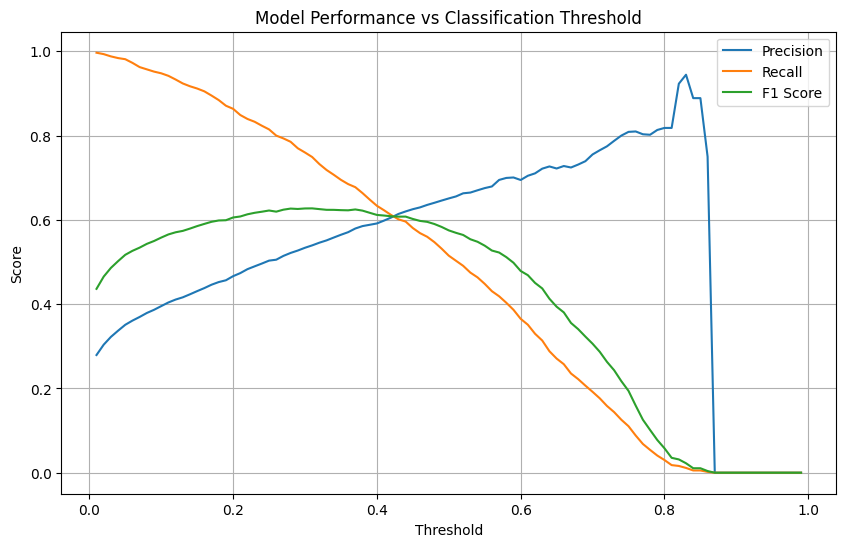

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(threshold_results["threshold"], threshold_results["precision"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1"], label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Model Performance vs Classification Threshold")

plt.legend()
plt.grid(True)

plt.show()

The relationship between precision, recall, and F1 score across different threshold values is shown in the figure above. As expected, increasing the threshold leads to higher precision at the cost of lower recall, reflecting the trade-off between identifying churners and avoiding false positives.

The F1 score reaches its maximum in the range of approximately 0.25–0.35, indicating the most balanced trade-off between precision and recall. Performance remains relatively stable within this interval, suggesting that the model is not overly sensitive to small changes in the threshold.

We therefore select a threshold within this range, as it provides a robust balance between identifying churners and maintaining reasonable precision, without relying on a single point estimate.

In [70]:
best_threshold_row = threshold_results.loc[threshold_results["f1"].idxmax()]
best_threshold_row

threshold       0.310000
accuracy        0.763756
precision       0.539499
recall          0.749164
f1              0.627275
tp           1120.000000
tn           3183.000000
fp            956.000000
fn            375.000000
auc             0.839131
pr_auc          0.634830
Name: 30, dtype: float64

In [71]:
threshold_results.sort_values("f1", ascending=False).head(10)

,threshold,accuracy,precision,recall,f1,tp,tn,fp,fn,auc,pr_auc
30,0.31,0.763756,0.539499,0.749164,0.627275,1120,3183,956,375,0.839131,0.63483
29,0.30,0.760206,0.533835,0.759866,0.627105,1136,3147,992,359,0.839131,0.63483
27,0.28,0.751864,0.521546,0.785284,0.626802,1174,3062,1077,321,0.839131,0.63483
28,0.29,0.755769,0.527256,0.769900,0.625884,1151,3107,1032,344,0.839131,0.63483
31,0.32,0.767306,0.545862,0.732441,0.625536,1095,3228,911,400,0.839131,0.63483
36,0.37,0.783990,0.579519,0.677592,0.624730,1013,3404,735,482,0.839131,0.63483
26,0.27,0.746539,0.514534,0.793311,0.624211,1186,3020,1119,309,0.839131,0.63483
32,0.33,0.770146,0.551335,0.718395,0.623875,1074,3265,874,421,0.839131,0.63483
33,0.34,0.773695,0.558078,0.707023,0.623783,1057,3302,837,438,0.839131,0.63483
34,0.35,0.776890,0.564674,0.694983,0.623088,1039,3338,801,456,0.839131,0.63483


### **Final Threshold Selection**

To complement the visual analysis, we examine specific threshold values and their corresponding classification metrics. The results show that the F1 score remains relatively stable across a range of thresholds between approximately 0.28 and 0.33, indicating that there is no sharply defined optimum.

As the threshold increases, precision improves while recall declines, reflecting the expected trade-off between avoiding false positives and capturing churners. Lower thresholds achieve higher recall at the cost of reduced precision, while higher thresholds improve precision but lead to a noticeable drop in recall.

A threshold of **0.31** is selected, as it achieves one of the highest F1 scores (0.627) while maintaining a balanced trade-off between precision (0.539) and recall (0.749). This choice avoids overly aggressive classification while still capturing a substantial proportion of churners.

Alternative thresholds in the range 0.30–0.32 provide very similar performance, confirming that the model is relatively stable with respect to threshold selection and does not rely on a narrowly tuned cutoff.

### Modeling and Threshold Selection Summary

In this section we will summarise final model and the teshhold selection.

In [72]:
print(model_4_fit.summary())

                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 5634
Model:                          Logit   Df Residuals:                     5623
Method:                           MLE   Df Model:                           10
Date:                Thu, 26 Mar 2026   Pseudo R-squ.:                  0.2727
Time:                        23:44:04   Log-Likelihood:                -2370.7
converged:                       True   LL-Null:                       -3259.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -1.8217      0.132    -13.835      0.000      -2.080      -1.564
tenure                                  -0.0313      

### **Interpretation of Final Model (Model 4)**

The final model coefficients are expressed in log-odds. For interpretability, each coefficient can be exponentiated to represent the multiplicative change in the odds of churn associated with a one-unit increase in the corresponding variable.

Several variables show a strong and statistically significant relationship with churn:

---

**Core behavioral and pricing variables**

- **Intercept** (`const` = -1.8217)  
  The intercept represents the baseline log-odds of churn for a customer in all reference categories with numerical variables at zero. While not directly interpretable in isolation, it reflects a relatively low baseline probability of churn.

- **tenure** (-0.0313)  
  Longer customer tenure is associated with lower churn risk. Each additional unit of tenure reduces the odds of churn by approximately 3% (exp(-0.0313) ≈ 0.97), indicating that more established customers are less likely to leave.

- **MonthlyCharges** (0.0267)  
  Higher monthly charges increase churn risk. A one-unit increase raises the odds of churn by approximately 2.7%, suggesting that more expensive plans are associated with higher attrition.

- **AdditionalInternetServicesCount** (-0.3149)  
  Customers with more additional services are significantly less likely to churn. Each additional service reduces the odds by roughly 27% (exp(-0.3149) ≈ 0.73), indicating that deeper product engagement is associated with higher retention.

---

**Demographics**

- **SeniorCitizenRelevel_Yes** (0.2569)  
  Senior customers have approximately 29% higher odds of churn (exp(0.2569) ≈ 1.29), indicating a meaningful demographic effect.

- **Dependents_Yes** (-0.1983)  
  Customers with dependents are less likely to churn, with approximately 18% lower odds (exp(-0.1983) ≈ 0.82), suggesting more stable customer relationships.

---

**Contract type**

Compared to month-to-month contracts:

- **Contract_One year** (-0.7227) → ~49% reduction in churn odds (exp(-0.7227) ≈ 0.49)  
- **Contract_Two year** (-1.5012) → ~78% reduction in churn odds (exp(-1.5012) ≈ 0.22)  

Contract type remains one of the strongest predictors, highlighting the importance of long-term commitment in reducing churn.

---

**Billing and payment behavior**

- **PaperlessBilling_Yes** (0.4347)  
  Customers using paperless billing have approximately 54% higher odds of churn (exp(0.4347) ≈ 1.54), potentially reflecting behavioral or segment differences.

- **PaymentMethod_bin_3_Electronic check** (0.4650)  
  Customers using electronic check have about 59% higher odds of churn (exp(0.4650) ≈ 1.59), making it one of the strongest churn indicators in the model.

- **PaymentMethod_bin_3_Mailed check** (-0.0159)  
  This variable shows a negligible and statistically insignificant effect (exp(-0.0159) ≈ 0.98, p = 0.883), indicating no meaningful difference in churn risk relative to the reference category. It is retained to preserve the structure of the categorical variable.

---

Overall, the final model identifies customer tenure, pricing, contract type, and selected behavioral and demographic characteristics as the primary drivers of churn. The model is both interpretable and parsimonious, retaining only variables that contribute meaningful predictive signal while maintaining strong performance.

### **Threshold Selection**

The logistic regression model produces estimated probabilities of churn, which must be converted into binary predictions using a classification threshold. The default threshold of 0.5 is arbitrary and may not be appropriate, particularly given the class imbalance in the dataset.

Ideally, the threshold would be determined based on the relative cost of false positives and false negatives. For example, failing to identify a customer who is likely to churn may be more costly than incorrectly targeting a customer who would have stayed. However, defining such costs requires additional business information (e.g., customer lifetime value or retention campaign effectiveness), which is not available in the current setting.

To address this, model performance is evaluated across a range of threshold values using out-of-fold predicted probabilities obtained from stratified cross-validation. This ensures that threshold selection is based on predictions for unseen data within the training set and avoids optimistic bias.

The relationship between threshold and classification performance is assessed using precision, recall, and F1 score. As expected, increasing the threshold improves precision while reducing recall, reflecting the trade-off between avoiding false positives and identifying churners.

The results show that the F1 score remains relatively stable across a range of thresholds (approximately 0.28–0.33), indicating that the model is not overly sensitive to the exact threshold choice. A threshold of **0.31** achieves one of the highest observed F1 scores (~0.627) while maintaining a balanced trade-off between precision (~0.539) and recall (~0.749).

This threshold is used as a reference point for evaluation. However, the selection performed in this section is exploratory and primarily intended to illustrate the trade-off between precision and recall. A final threshold will be determined later in a unified decision framework to ensure consistency across all models.

**Model Persistence**

To ensure reproducibility and enable future use, the final model is saved to disk along with the metadata required for preprocessing and prediction.

Because the modeling pipeline includes manual feature preparation, it is necessary to persist not only the fitted model but also the associated feature configuration (e.g., variable definitions and encoding structure) and the selected classification threshold.

This ensures that future predictions can be generated using a consistent feature space without reconstructing the preprocessing pipeline.

In [73]:
import pickle

X_train, y_train = prepare_linear_features(
    df=train_df,
    categorical_cols=model_4_categorical_cols,
    numerical_cols=model_4_numerical_cols,
    categorical_orders=categorical_orders
)

reference_columns = X_train.drop(columns="const").columns.tolist()

model_artifacts = {
    # model
    "model": model_4_fit,
    # for preparation of data in future
    "categorical_cols": model_4_categorical_cols,
    "numerical_cols": model_4_numerical_cols,
    "categorical_orders": categorical_orders,
    "target_col":target_col,
    "reference_columns": reference_columns,
    # treshhold
    "threshold": 0.31
}

with open("./models/logistic_regression_final.pkl", "wb") as f:
    pickle.dump(model_artifacts, f)

## Final Model Evaluation on Test Data

With the model specification and classification threshold finalized, we evaluate performance on the held-out test dataset. This provides an unbiased estimate of how the model is expected to perform on new, unseen data.

In [74]:
# create test design matrix aligned to training reference
X_test, y_test = prepare_linear_features(
    df=test_df,
    categorical_cols=model_4_categorical_cols,
    numerical_cols=model_4_numerical_cols,
    categorical_orders=categorical_orders,
    target_col=target_col,
    reference_columns = reference_columns # from training design matrix to ensure alignment of dummy variables
)

# predict probabilities on test set
y_test_prob = model_4_fit.predict(X_test)

# apply threshold
threshold = 0.31
y_test_pred = (y_test_prob >= threshold).astype(int)

metrics = compute_classification_metrics(y_true = y_test, y_pred = y_test_pred, y_prob=y_test_prob)

metrics_df = (
    pd.DataFrame([metrics])
    .drop(columns=["tp", "tn", "fp", "fn"])
    .round(4)
)

metrics_df

,accuracy,precision,recall,f1,auc,pr_auc
0,0.7672,0.5469,0.7166,0.6204,0.8342,0.6552


In [75]:
conf_matrix = pd.DataFrame(
    [[metrics["tn"], metrics["fp"]],
     [metrics["fn"], metrics["tp"]]],
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

conf_matrix

,Pred 0,Pred 1
Actual 0,813,222
Actual 1,106,268


### **Test Set Evaluation**

The model achieves an accuracy of approximately 76.7%, which is only moderately higher than the baseline accuracy implied by the class distribution. Given the churn rate of around 24%, accuracy alone is not a particularly informative metric in this setting.

A more meaningful evaluation comes from examining precision, recall, and the confusion matrix. The model correctly identifies approximately 71.7% of churners (recall = 0.7166), indicating strong ability to capture at-risk customers. Precision of 0.5469 suggests that slightly more than half of the predicted churners are correctly identified, reflecting a moderate level of false positives.

The confusion matrix further illustrates this trade-off:

- True Negatives: 813  
- False Positives: 222  
- False Negatives: 106  
- True Positives: 268  

This indicates that while the model captures a large portion of churners, it also flags a non-trivial number of non-churning customers as high risk.

From a ranking perspective, the model performs well. The ROC-AUC of 0.834 indicates strong discriminative ability, meaning that churners are consistently ranked above non-churners. In addition, the PR-AUC of 0.655 provides a more informative view in this imbalanced setting, confirming that the model maintains reasonable precision while identifying a substantial proportion of churners.

Overall, the model demonstrates solid discriminatory power and provides a meaningful improvement over naive classification, particularly in its ability to identify and prioritize churners.

While accuracy remains close to the baseline, the model provides clear value as a prioritization tool. In practice, it is best used to rank customers by risk and focus retention efforts on the highest-risk segments, rather than as a strict binary classifier.

## Executive Summary

The objective of this model is not to perfectly classify customers into “churn” and “no churn” groups, but to identify and rank customers based on their likelihood of churning.

While the model achieves an accuracy of approximately 76.7%, this metric is not particularly informative given the class imbalance in the data. Instead, the strength of the model lies in its ability to differentiate between higher-risk and lower-risk customers, as reflected by a strong ROC-AUC of 0.834. The PR-AUC of 0.655 further confirms that the model performs well in identifying churners while maintaining reasonable precision in this imbalanced setting.

In practical terms, the model effectively orders customers from most likely to churn to least likely to churn. This ranking can be used directly to prioritize retention efforts. For example, targeted interventions (such as offers or outreach) can be focused on customers with the highest predicted churn risk.

The chosen classification threshold provides one possible operational decision rule, achieving a balanced trade-off between precision (~0.547) and recall (~0.717). However, the threshold itself is not the primary output of the model. The probability score is more valuable, as it enables flexible decision-making depending on business objectives, available resources, and cost considerations.

Overall, the model should be viewed as a decision-support tool rather than a system for perfectly predicting individual outcomes. It provides a practical and interpretable framework for identifying at-risk customers and enabling more efficient, targeted retention strategies.

This model serves as a transparent and interpretable baseline against which more complex models will be evaluated in subsequent stages of the project.

## Operational Use Case

In a production setting, the model would be used to score customers on a regular basis (e.g., daily or weekly), producing a churn probability for each active customer.

These scores can be used to prioritize retention efforts, with business teams focusing on customers above a selected threshold (e.g., ~0.31) or within the highest-risk segments. At this threshold, the model captures a substantial proportion of churners (recall ≈ 0.72) while maintaining reasonable precision (~0.55), making it suitable for targeted intervention.

The specific intervention strategy (e.g., discounts, outreach, or service adjustments) would depend on business constraints and cost considerations. The classification threshold can be adjusted dynamically based on available resources and the desired trade-off between recall (capturing more churners) and precision (avoiding unnecessary interventions).

Importantly, the probability score itself provides flexibility beyond a fixed threshold. Customers can be ranked and segmented into risk tiers (e.g., top 5%, 10%, or 20%), allowing retention strategies to scale with operational capacity and budget.

In this context, the model serves as a prioritization and decision-support tool rather than a strict classification system, enabling more efficient and targeted allocation of retention efforts.